# Next Word Predictor using Encoder
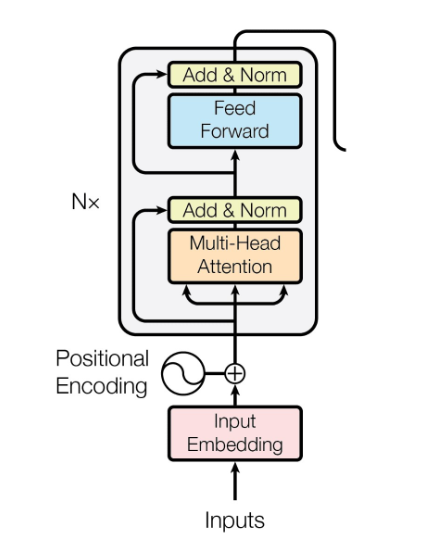

# Import Libraries

In [8]:
import pandas as pd
import numpy as np

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [11]:
import math
import re
import time

# Check Device Availability

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Make Data

In [13]:
with open("data.txt", "r", encoding="utf-8") as f:
    text = f.read()
len(text)

54521

# Data Preprocessing

In [14]:
def split_sentences(text: str):
    # Custom rule: split on . ! ? or newlines
    return re.split(r'(?<=[.!?])\s+|\n+', text)

def preprocess_text(text: str) -> str:

    text = text.lower()

    text = re.sub(r'[\\|]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"won't", "will not", text)

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[ \t]+', ' ', text)  # keep newline
    text = text.strip()

    return text

def preprocess_document(text: str) -> list:
    sentences = split_sentences(text)
    return [preprocess_text(s) for s in sentences]

In [15]:
preprocessed_sentences = preprocess_document(text)
len(preprocessed_sentences)

552

# Tokenizer

In [16]:
def tokenize(text: list) -> list[str]:
  tokens = []
  for sentence in text:
    token = sentence.split()
    tokens.extend(token)
  return tokens

In [17]:
tokens = tokenize(preprocessed_sentences)
len(tokens)

8148

# Vocabulary

In [18]:
def make_vocabulary(tokens: list) -> dict:
  vocabulary = {"<unk>": 0}

  for token in tokens:
    if token not in vocabulary:
      vocabulary[token] = len(vocabulary)
  return vocabulary

In [19]:
vocabulary = make_vocabulary(tokens)
len(vocabulary)

1912

# String Sentence to Number Sentence

In [20]:
def text_to_indices(preprocessed_sentences: list[str], vocabulary: dict[str, int]) -> list[list[int]]:
    """
    Convert each preprocessed sentence into a list of integer token indices
    using the provided vocabulary. Unknown tokens map to 0.

    Args:
        preprocessed_sentences (list[str]): List of pre-tokenized, preprocessed sentences.
        vocabulary (dict[str, int]): Mapping from token to numeric index.

    Returns:
        list[list[int]]: A list of numeric sequences.
    """

    input_numeric_sentences = []

    for sentence in preprocessed_sentences:
        # Handle empty or whitespace-only sentences
        if sentence.strip() == "":
            input_numeric_sentences.append([0])
            continue

        sequence = [
            vocabulary.get(token, 0)   # Use 0 for unknown tokens
            for token in sentence.split()
        ]

        input_numeric_sentences.append(sequence)

    return input_numeric_sentences

In [21]:
x = ["hello visit have nlp fun", " ", "nlp is also an acronym for "]
text_to_indices(x, vocabulary)

[[0, 0, 57, 4, 0], [0], [4, 5, 292, 107, 0, 157]]

In [22]:
preprocessed_sentences[5]

'natural language processing nlp is one of the hottest areas of artificial intelligence ai thanks to applications like text generators that compose coherent essays chatbots that fool people into thinking theyre sentient and texttoimage programs that produce photorealistic images of anything you can describe'

In [23]:
input_numaric_sentences = text_to_indices(preprocessed_sentences, vocabulary)
input_numaric_sentences[5]

[1,
 2,
 3,
 4,
 5,
 25,
 8,
 6,
 26,
 27,
 8,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 11,
 37,
 38,
 39,
 40,
 11,
 41,
 42,
 43,
 44,
 45,
 46,
 19,
 47,
 48,
 11,
 49,
 50,
 51,
 8,
 52,
 53,
 12,
 54]

# Make Training Sequence (Target Columns)

In [24]:
def training_sequence(numaric_sentence: list[list[int]]) -> list[list[int]]:
  training_sequences = []
  for sentence in numaric_sentence:
    for i in range(1, len(sentence)):
      # print(i[j], end=" ")
      training_sequences.append(sentence[ : i+1])
  return training_sequences

In [25]:
training_sequences = training_sequence(input_numaric_sentences)
training_sequences[17]

[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 2, 14, 6, 15]

In [26]:
len(training_sequences)

7614

# Padding

In [27]:
max_len = max([len(s) for s in training_sequences])
max_len

51

In [28]:
[0]* (max_len - len(training_sequences[7])) + training_sequences[7]
#

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 2,
 3,
 5,
 6,
 7]

In [29]:
def padded_sequences(training_sequences, max_len):
  # max_len = max([len(s) for s in training_sequences])
  seq = []
  for sequence in training_sequences:
    with_pad = [0]* (max_len - len(sequence)) + sequence
    seq.append(with_pad)
  return torch.tensor(seq)

In [30]:
training_padded_sequences = padded_sequences(training_sequences, max_len)
training_padded_sequences

tensor([[   0,    0,    0,  ...,    0,    1,    2],
        [   0,    0,    0,  ...,    1,    2,    3],
        [   0,    0,    0,  ...,    2,    3,    4],
        ...,
        [   0,    0,    0,  ..., 1433,   79, 1910],
        [   0,    0,    0,  ...,   79, 1910,  157],
        [   0,    0,    0,  ..., 1910,  157, 1911]])

In [31]:
len(training_padded_sequences[40])

51

# Separate `X`, `y`

In [32]:
X = training_padded_sequences[:, : -1]
y = training_padded_sequences[:, -1]

# Train Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)
X_train.shape, X_test.shape

(torch.Size([6091, 50]), torch.Size([1523, 50]))

# Custom Dataset Class

In [34]:
class WordPredDataset(Dataset):
  def __init__(self, features, labels):
    self.features = features
    self.labels = labels

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [35]:
train_dataset = WordPredDataset(X_train, y_train)
test_dataset = WordPredDataset(X_test, y_test)

# DataLoader Class

In [36]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=16
)

# LSTM Model Build

## 🛠️ Step 1: Positional Encoding
You need a fixed layer to inject sequential information into the input embeddings.

In [37]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        # Create a tensor of shape (max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)

        # Calculate the divisor term (10000^(2i/d_model))
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))

        pe = torch.zeros(max_len, d_model)

        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension and register as buffer (not a trainable parameter)
        self.pe = pe.unsqueeze(0)
        self.register_buffer('pe_buffer', self.pe)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, d_model)
        # Add positional encoding to the input embedding
        x = x + self.pe_buffer[:, :x.size(1)]
        return x

## 🔑 Step 2: Multi-Head Attention
PyTorch provides nn.MultiheadAttention, which performs the core scaled dot-product attention operation efficiently.

A single Encoder Layer will use two main sub-components:

1. The Multi-Head Attention Block

In [38]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerEncoderLayer, self).__init__()

        # Multi-Head Attention (MHA)
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)

        # Feed-Forward Network (FFN)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        # Normalization and Dropout layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # 1. Self-Attention Sub-Layer
        # MHA output needs its own input for Q, K, and V (Self-Attention)
        attn_output, attn_weights = self.self_attn(src, src, src,
                                                   attn_mask=src_mask,
                                                   key_padding_mask=src_key_padding_mask)

        # Add & Norm (Residual Connection + Layer Normalization)
        src = src + self.dropout1(attn_output)
        src = self.norm1(src)

        # 2. Feed-Forward Sub-Layer
        ffn_output = self.linear2(self.dropout(F.relu(self.linear1(src))))

        # Add & Norm (Residual Connection + Layer Normalization)
        src = src + self.dropout2(ffn_output)
        src = self.norm2(src)

        return src

## 💻 Step 3: The Full Transformer Encoder
The full encoder is a stack of multiple identical TransformerEncoderLayer modules.

In [39]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout=0.1, max_len=512):
        super(TransformerEncoder, self).__init__()

        # Input: Embedding + Positional Encoding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        # Create a stack of N encoder layers
        encoder_layer = TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
        self.encoder_stack = nn.ModuleList([encoder_layer for _ in range(num_layers)])

        # Optional: Final Layer Norm, often used before the classification head
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # src shape: (batch_size, sequence_length) -> token indices

        # 1. Embed and Add Position
        src = self.token_embedding(src) * math.sqrt(self.token_embedding.embedding_dim) # Scale embedding
        src = self.positional_encoding(src)
        src = self.dropout(src)

        # 2. Pass through the stack of layers
        for layer in self.encoder_stack:
            src = layer(src, src_mask, src_key_padding_mask)

        src = self.final_norm(src)

        # Output shape: (batch_size, sequence_length, d_model)
        return src

## Sequence Classification

In [40]:
class TransformerForClassification(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, num_classes, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout)

        # classification head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        encoded = self.encoder(x)               # (B, L, D)
        pooled  = encoded[:, 0, :]              # use first token (CLS)
        logits  = self.fc(pooled)               # (B, num_classes)
        return logits


## Transformer Language Model

In [41]:
class TransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4,
                 dim_feedforward=1024, dropout=0.1, max_len=512):
        super().__init__()

        self.encoder = TransformerEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            max_len=max_len
        )

        # Language modeling head
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        encoded = self.encoder(x, src_mask=mask)     # (B, L, D)
        logits  = self.lm_head(encoded)              # (B, L, vocab)
        return logits

## Add a CAUSAL MASK

In [42]:
def generate_causal_mask(seq_len, device='cpu'):
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask.to(device)

## Model Creation

In [43]:
model = TransformerLanguageModel(len(vocabulary)).to(device)
model

TransformerLanguageModel(
  (encoder): TransformerEncoder(
    (token_embedding): Embedding(1912, 256)
    (positional_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (encoder_stack): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (final_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=256, out_features=1

## Parameters Init

In [44]:
epochs = 50
learning_rate = 0.001

## Loss and Optimizer

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

## Training Loop

In [47]:
for epoch in range(epochs):
    model.train()
    losses = []

    for features, labels in train_loader:
        features = features.to(device)       # shape (B, L)
        labels = labels.to(device)

        # Prepare inputs and next-token labels
        inputs = features[:, :-1]
        labels = features[:, 1:]

        # Create causal mask
        seq_len = inputs.size(1)
        mask = generate_causal_mask(seq_len, device)

        # Forward pass
        logits = model(inputs, mask)      # (B, L-1, vocab)

        # Compute loss
        loss = criterion(
            logits.view(-1, logits.size(-1)),    # flatten
            labels.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(losses):.4f}")

Epoch 1/50, Loss: 1.1679
Epoch 2/50, Loss: 0.4967
Epoch 3/50, Loss: 0.3315
Epoch 4/50, Loss: 0.2906
Epoch 5/50, Loss: 0.2740
Epoch 6/50, Loss: 0.2637
Epoch 7/50, Loss: 0.2587
Epoch 8/50, Loss: 0.2564
Epoch 9/50, Loss: 0.2534
Epoch 10/50, Loss: 0.2536
Epoch 11/50, Loss: 0.2501
Epoch 12/50, Loss: 0.2500
Epoch 13/50, Loss: 0.2440
Epoch 14/50, Loss: 0.2395
Epoch 15/50, Loss: 0.2349
Epoch 16/50, Loss: 0.2321
Epoch 17/50, Loss: 0.2320
Epoch 18/50, Loss: 0.2283
Epoch 19/50, Loss: 0.2272
Epoch 20/50, Loss: 0.2262
Epoch 21/50, Loss: 0.2250
Epoch 22/50, Loss: 0.2245
Epoch 23/50, Loss: 0.2219
Epoch 24/50, Loss: 0.2226
Epoch 25/50, Loss: 0.2249
Epoch 26/50, Loss: 0.2237
Epoch 27/50, Loss: 0.2183
Epoch 28/50, Loss: 0.2170
Epoch 29/50, Loss: 0.2185
Epoch 30/50, Loss: 0.2209
Epoch 31/50, Loss: 0.2193
Epoch 32/50, Loss: 0.2185
Epoch 33/50, Loss: 0.2154
Epoch 34/50, Loss: 0.2145
Epoch 35/50, Loss: 0.2158
Epoch 36/50, Loss: 0.2189
Epoch 37/50, Loss: 0.2153
Epoch 38/50, Loss: 0.2142
Epoch 39/50, Loss: 0.

# Predictions

In [48]:
def predict_next_word(model, vocab, text, device='cpu', max_sequence_length=None):
    model.eval()

    # index → token
    idx2word = {i: w for w, i in vocab.items()}

    # Preprocess the input text (assuming it's a single sentence) and get tokens
    current_tokens = preprocess_text(text).split()

    # Convert tokens to indices
    token_ids = [vocab.get(token, 0) for token in current_tokens]

    # Pad/truncate the sequence if max_sequence_length is provided
    if max_sequence_length is not None:
        if len(token_ids) > max_sequence_length:
            token_ids = token_ids[-max_sequence_length:]  # Truncate from the left
        elif len(token_ids) < max_sequence_length:
            token_ids = [0] * (max_sequence_length - len(token_ids)) + token_ids  # Pad with 0s at the beginning

    # Convert to tensor, add batch dimension (B=1)
    # The input to the model should be (batch_size, sequence_length)
    x = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)   # Shape (1, L)

    # Create causal mask
    # The mask sequence length should match the input tensor's sequence length
    seq_len = x.size(1)
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).to(device)
    mask = mask.masked_fill(mask == 1, float('-inf'))

    # Forward pass
    with torch.no_grad():
        logits = model(x, mask)      # (1, L, vocab_size)

    # Get last token's distribution
    last_logits = logits[0, -1]      # (vocab_size)
    pred_idx = torch.argmax(last_logits).item()

    # Convert prediction to word
    pred_word = idx2word.get(pred_idx, "<unk>")

    return f"{text} {pred_word}"


In [49]:
total_word = 10
pred_text = "A full transformer encoder typically"

for i in range(total_word):
  # Pass the max_len obtained during training for consistent padding
  next_word = predict_next_word(model, vocabulary, pred_text, device, max_sequence_length=max_len)
  print(next_word)
  pred_text = next_word
  time.sleep(1)

A full transformer encoder typically that
A full transformer encoder typically that can
A full transformer encoder typically that can be
A full transformer encoder typically that can be efficiently
A full transformer encoder typically that can be efficiently feature
A full transformer encoder typically that can be efficiently feature extraction
A full transformer encoder typically that can be efficiently feature extraction most
A full transformer encoder typically that can be efficiently feature extraction most deep
A full transformer encoder typically that can be efficiently feature extraction most deep learning
A full transformer encoder typically that can be efficiently feature extraction most deep learning engineers
